In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
import os


In [2]:
#load the data
df = pd.read_csv("weekly_with_CCFI.csv")
print(df.head)

<bound method NDFrame.head of            week      IPCI  Brent_Oil_Avg  CCFI_weekly_avg
0    2019/12/30  4.030125        67.9175           681.52
1      2020/1/6  5.543432        66.5940           691.88
2     2020/1/13  2.430611        64.4320           725.85
3     2020/1/20  2.418202        61.9700           722.91
4     2020/1/27  2.907034        59.0180           720.53
..          ...       ...            ...              ...
288   2025/9/29  0.000000            NaN              NaN
289   2025/10/6  0.000000            NaN              NaN
290  2025/10/27  3.108907            NaN              NaN
291   2025/11/3  0.000000            NaN              NaN
292   2025/12/1  0.000000            NaN              NaN

[293 rows x 4 columns]>


In [3]:
df['week'] = pd.to_datetime(df['week'])
df.set_index('week', inplace=True)
df = df[['IPCI', 'Brent_Oil_Avg','CCFI_weekly_avg']].dropna()
df = df.iloc[:180, :] #使用2019-12-30至2023-06-05的数据
print(df.head)

<bound method NDFrame.head of                 IPCI  Brent_Oil_Avg  CCFI_weekly_avg
week                                                
2019-12-30  4.030125        67.9175           681.52
2020-01-06  5.543432        66.5940           691.88
2020-01-13  2.430611        64.4320           725.85
2020-01-20  2.418202        61.9700           722.91
2020-01-27  2.907034        59.0180           720.53
...              ...            ...              ...
2023-05-08  4.165577        76.0020           745.17
2023-05-15  4.116525        75.7080           707.57
2023-05-22  2.881514        76.8800           703.31
2023-05-29  4.029959        74.3440           699.48
2023-06-05  6.507382        76.1400           679.75

[180 rows x 3 columns]>


In [4]:

#OLS
Y = df["CCFI_weekly_avg"]

# Model1：Brent_Oil_Avg=>CCFI
X1 = sm.add_constant(df[["Brent_Oil_Avg"]])
model1 = sm.OLS(Y, X1).fit()

# Model2: IPCI=>CCFI
X2 = sm.add_constant(df[["IPCI"]])
model2 = sm.OLS(Y, X2).fit()

# Model3: IPCI,Brent_Oil_Avg=>CCFI
X3 = sm.add_constant(df[["IPCI", "Brent_Oil_Avg"]])
model3 = sm.OLS(Y, X3).fit()

# Output
print("=== 模型1：仅 Brent_Oil_Avg ===")
print(model1.summary())

print("=== 模型2：仅 IPCI ===")
print(model2.summary())

print("\n=== 模型3：IPCI + Brent_Oil_Avg ===")
print(model3.summary())

=== 模型1：仅 Brent_Oil_Avg ===
                            OLS Regression Results                            
Dep. Variable:        CCFI_weekly_avg   R-squared:                       0.462
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                     153.0
Date:                Mon, 30 Jun 2025   Prob (F-statistic):           9.26e-26
Time:                        18:43:36   Log-Likelihood:                -1381.1
No. Observations:                 180   AIC:                             2766.
Df Residuals:                     178   BIC:                             2773.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            1

模型1的拟合优度为0.462，模型2的拟合优度是0.435，模型3的拟合优度为0.648；模型3相对于模型1和2拟合优度有所提升，说明拥堵指数和石油价格中所包含的信息均没有被其他经济变量所覆盖

In [5]:
#Data_check
#ADF
def adf_test(series, significance_level=0.05):
    result = adfuller(series)
    p_value = result[1]
    if p_value < significance_level:
        print(f"P-Value = {p_value} => Reject null hypothesis (data is stationary)")
    else:
        print(f"P-Value = {p_value} => Fail to reject null hypothesis (data is not stationary)")
    print(f"ADF Statistic: {result[0]}")
    print(f"Number Of Lags: {result[2]}")
    print(f"Number Of Observations Used For ADF Regression: {result[3]}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")
for column in ['IPCI', 'Brent_Oil_Avg',"CCFI_weekly_avg"]:
    print(f"\nADF Test for {column}:")
    adf_test(df[column])


ADF Test for IPCI:
P-Value = 0.22670491729247905 => Fail to reject null hypothesis (data is not stationary)
ADF Statistic: -2.1452702217884174
Number Of Lags: 10
Number Of Observations Used For ADF Regression: 169
Critical Values:
   1%: -3.469648263987657
   5%: -2.878798906308495
   10%: -2.5759713094779593

ADF Test for Brent_Oil_Avg:
P-Value = 0.7344623816539171 => Fail to reject null hypothesis (data is not stationary)
ADF Statistic: -1.0503450614194556
Number Of Lags: 0
Number Of Observations Used For ADF Regression: 179
Critical Values:
   1%: -3.4674201432469816
   5%: -2.877826051844538
   10%: -2.575452082332012

ADF Test for CCFI_weekly_avg:
P-Value = 0.5213691423343881 => Fail to reject null hypothesis (data is not stationary)
ADF Statistic: -1.5244788216916785
Number Of Lags: 4
Number Of Observations Used For ADF Regression: 175
Critical Values:
   1%: -3.4682803641749267
   5%: -2.8782017240816327
   10%: -2.5756525795918366


三个序列均不平稳，分别对其做一阶差分

In [6]:
#diff process
df_diff = df.diff().dropna()
for col in df_diff.columns:
    p_value = adfuller(df_diff[col])[1]
    print(f"{col} 一阶差分后 ADF p-value: {p_value}")

IPCI 一阶差分后 ADF p-value: 0.005152700830926389
Brent_Oil_Avg 一阶差分后 ADF p-value: 5.065020786113069e-24
CCFI_weekly_avg 一阶差分后 ADF p-value: 0.028281762766287667


一阶差分后三个序列均平稳

In [7]:
from statsmodels.tsa.api import VAR
df_diff.columns = ['dIPCI', 'dBrent_Oil', 'dCCFI']
model = VAR(df_diff)
lag_order_selection = model.select_order(maxlags=8)
print(lag_order_selection.summary()) 

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       13.91      13.97*   1.099e+06       13.93
1       13.87       14.09   1.054e+06       13.96
2       13.75       14.13   9.359e+05       13.91
3       13.57       14.12   7.851e+05      13.80*
4      13.51*       14.22  7.356e+05*       13.80
5       13.57       14.46   7.868e+05       13.93
6       13.65       14.70   8.517e+05       14.08
7       13.72       14.93   9.126e+05       14.21
8       13.76       15.14   9.538e+05       14.32
-------------------------------------------------


C:\Users\Administrator\anaconda3\envs\myenv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


In [8]:
optimal_lag = lag_order_selection.selected_orders['aic']  #select AIC 
model_fitted = model.fit(optimal_lag)
print(model_fitted.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 30, Jun, 2025
Time:                     18:43:37
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    14.1650
Nobs:                     175.000    HQIC:                   13.7458
Log likelihood:          -1883.67    FPE:                    701194.
AIC:                      13.4597    Det(Omega_mle):         565560.
--------------------------------------------------------------------
Results for equation dIPCI
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 0.024733         0.274296            0.090           0.928
L1.dIPCI             -0.573242         0.076992           -7.446           0.000
L1.dBrent_Oil        -0.049209         0.075367           -0

In [9]:
#Granger Causality Test
#dIPCI=>dCCFI
granger_result = model_fitted.test_causality(causing='dCCFI', caused='dIPCI', kind='f')
print(granger_result.summary())
#dOil=>dCCFI
granger_result = model_fitted.test_causality(causing='dCCFI', caused='dBrent_Oil', kind='f')
print(granger_result.summary())
#dIPCI,dOil=>dCCFI
granger_result = model_fitted.test_causality(causing='dCCFI', caused=['dIPCI','dBrent_Oil'], kind='f')
print(granger_result.summary())

Granger causality F-test. H_0: dCCFI does not Granger-cause dIPCI. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
         3.070          2.390   0.016 (4, 486)
----------------------------------------------
Granger causality F-test. H_0: dCCFI does not Granger-cause dBrent_Oil. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
        0.3458          2.390   0.847 (4, 486)
----------------------------------------------
Granger causality F-test. H_0: dCCFI does not Granger-cause [dIPCI, dBrent_Oil]. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
         1.721          1.957   0.091 (8, 486)
----------------------------------------------


In [10]:
#模型稳定性
is_stable = model_fitted.is_stable(verbose=True)
print("模型稳定性：", "稳定" if is_stable else "不稳定")

Eigenvalues of VAR(1) rep
0.8927688573581285
0.8047086888733165
0.8047086888733165
0.43773963593832804
0.43773963593832804
0.7076693710271721
0.7076693710271721
0.5545381726738332
0.5545381726738332
0.6226777920374404
0.503497770111389
0.503497770111389
模型稳定性： 稳定


In [11]:
#残差自相关检验
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = model_fitted.resid

for col in residuals.columns:
    print(f"\n残差自相关检验：{col}")
    lb_test = acorr_ljungbox(residuals[col], lags=[10], return_df=True)
    print(lb_test)


残差自相关检验：dIPCI
      lb_stat  lb_pvalue
10  11.301549   0.334512

残差自相关检验：dBrent_Oil
    lb_stat  lb_pvalue
10  7.11624   0.714428

残差自相关检验：dCCFI
     lb_stat  lb_pvalue
10  3.214483   0.975916


残差为白噪声

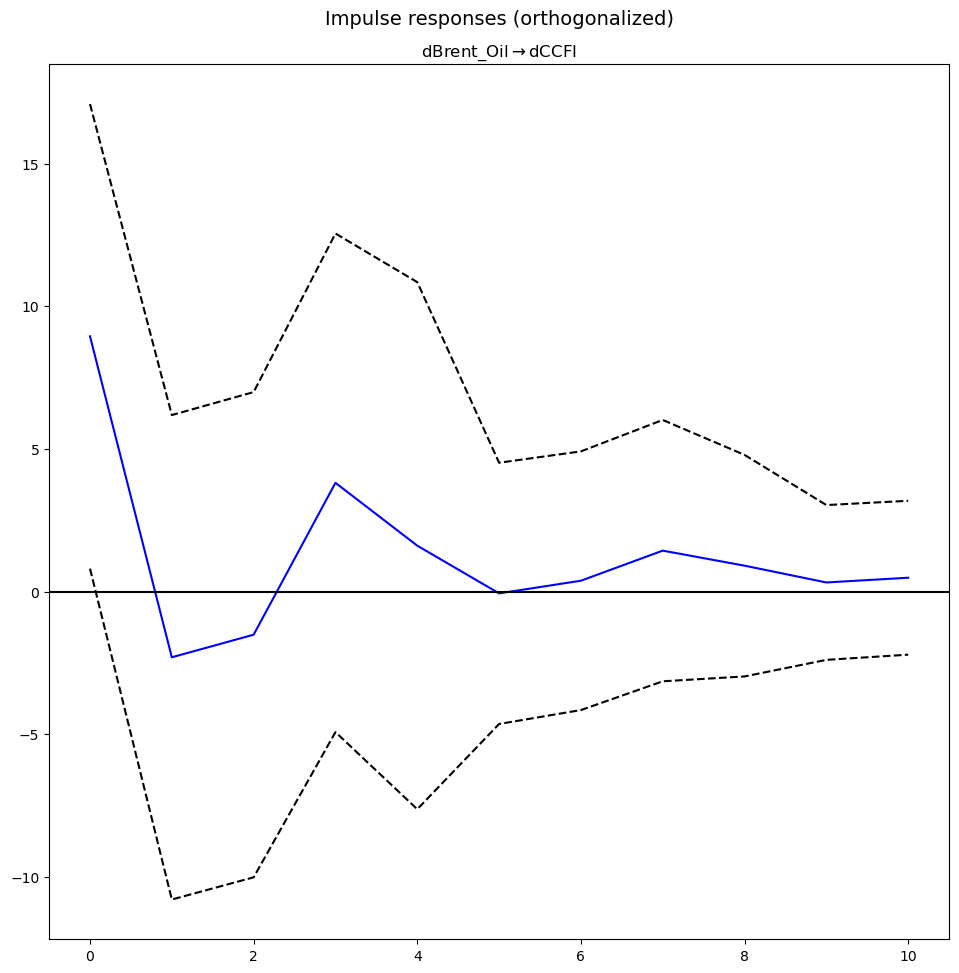

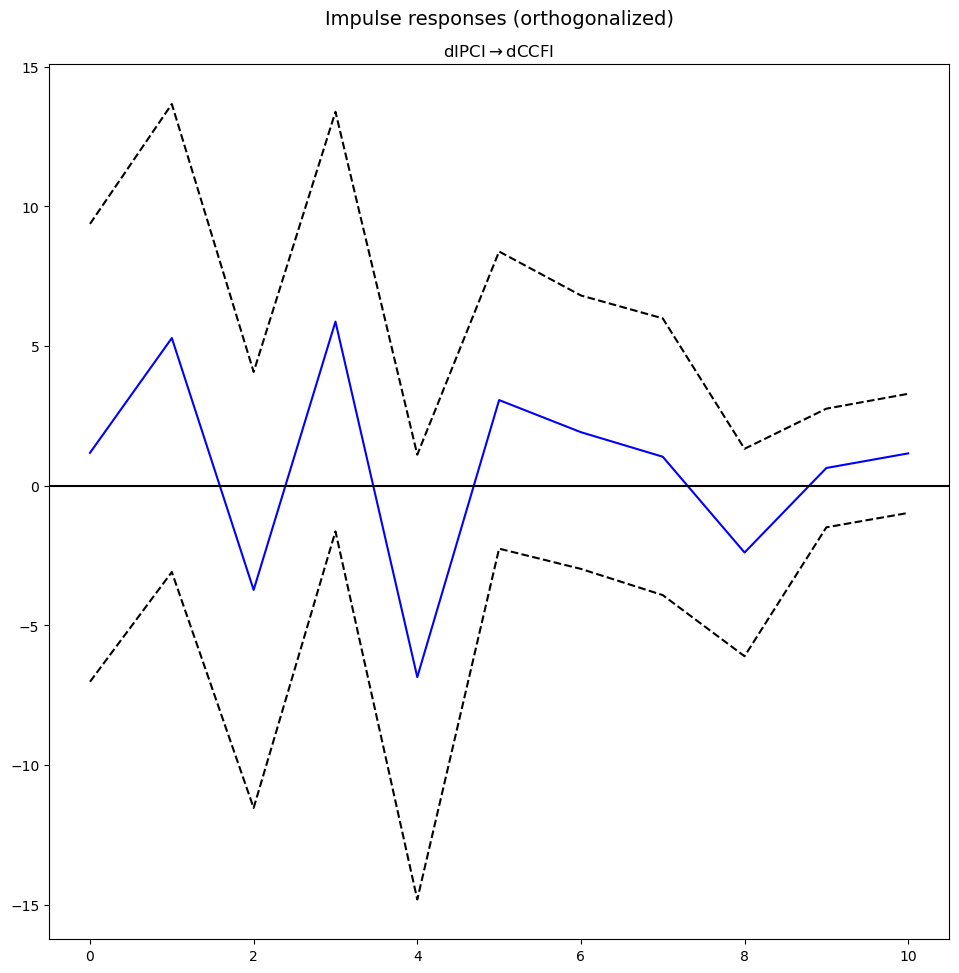

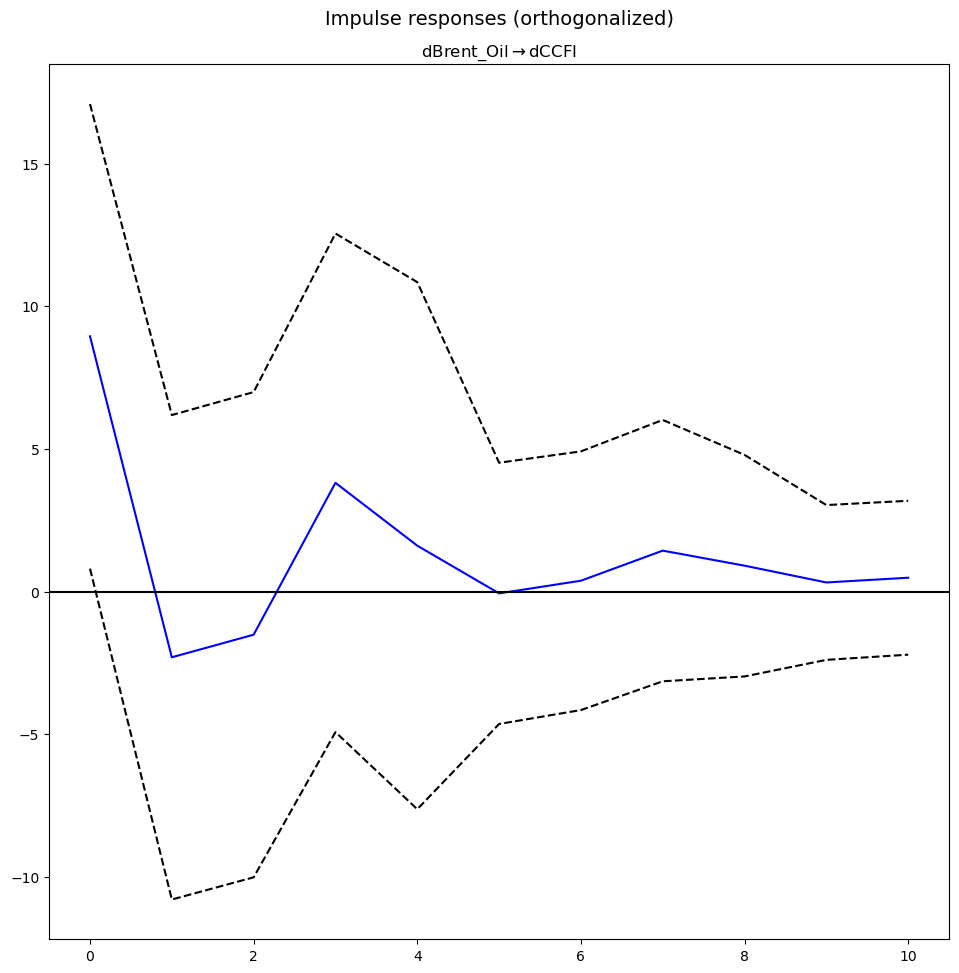

In [12]:
#IRF
irf = model_fitted.irf(10)
irf.plot(orth=True, impulse='dIPCI', response='dCCFI')
irf.plot(orth=True, impulse='dBrent_Oil', response='dCCFI')

In [13]:
#Forecast
forecast_diff = model_fitted.forecast(y=df_diff.values, steps=15)

In [14]:
last_row = df.iloc[-1].values
forecast_values = [last_row + forecast_diff[0]]

# 每一步累加前一预测值
for i in range(1, 15):
    forecast_values.append(forecast_values[-1] + forecast_diff[i])

forecast_array = np.array(forecast_values)
forecast_df = pd.DataFrame(forecast_array, columns=[ "IPCI", "Brent_Oil_Avg","CCFI"])

# 添加日期索引，从2025-02-03开始，每周递增
forecast_dates = pd.date_range(start="2023-06-12", periods=15, freq="W-MON")
forecast_df.index = forecast_dates
forecast_df.index.name = "week"

# Step 7: 显示或保存结果
print(forecast_df.head)
forecast_df.to_csv("Forecast_df_624.csv")

<bound method NDFrame.head of                 IPCI  Brent_Oil_Avg        CCFI
week                                           
2023-06-12  4.437231      76.399002  666.474507
2023-06-19  4.074438      76.132726  659.396573
2023-06-26  4.163709      76.296925  655.231783
2023-07-03  4.363023      76.500313  637.550060
2023-07-10  4.599128      76.307139  632.473000
2023-07-17  4.386891      76.342644  628.296974
2023-07-24  4.048615      76.355288  621.858006
2023-07-31  4.074511      76.361370  613.670980
2023-08-07  4.300265      76.426540  609.076464
2023-08-14  4.282773      76.462400  604.975569
2023-08-21  4.102182      76.478744  600.551483
2023-08-28  4.039882      76.524578  596.104568
2023-09-04  4.111316      76.592768  592.284700
2023-09-11  4.144779      76.651814  588.807791
2023-09-18  4.092937      76.702128  585.695792>


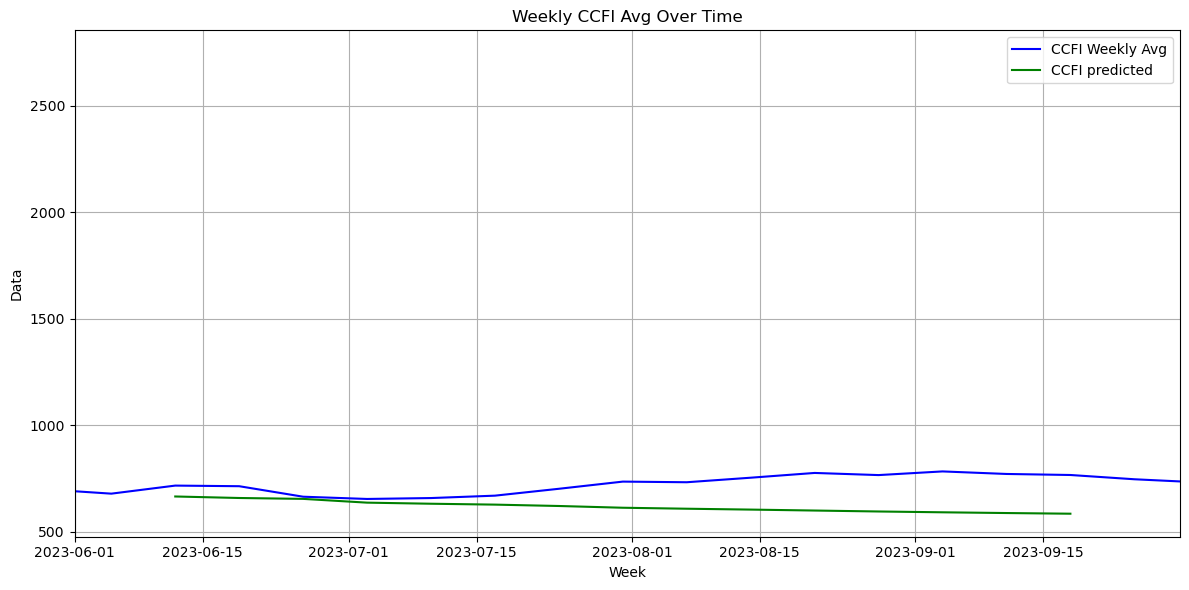

In [16]:
#可视化
df_original = pd.read_csv("weekly_with_CCFI.csv")
df_original['week'] = pd.to_datetime(df_original['week'])

df_forecast_draw = pd.read_csv("Forecast_df_624.csv")
df_forecast_draw['week'] = pd.to_datetime(df_forecast_draw['week'])

plt.figure(figsize=(12, 6))
plt.xlim(pd.to_datetime('2023-06-01'), pd.to_datetime('2023-09-30'))


plt.plot(df_original['week'], df_original['CCFI_weekly_avg'], label='CCFI Weekly Avg', color='blue')
plt.plot(df_forecast_draw['week'],df_forecast_draw['CCFI'],label='CCFI predicted',color='green')
plt.xlabel('Week')
plt.ylabel('Data')
plt.title('Weekly CCFI Avg Over Time')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()